# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the cleaned HR dataset, identify patterns related to employee attrition, and generate meaningful business insights using statistical analysis and data visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/hr_attrition_cleaned.csv")

In [3]:
sns.set_theme(style="whitegrid")

### Business Question 1 -- How many employees have left the company?

In [4]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [5]:
df["Attrition"].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

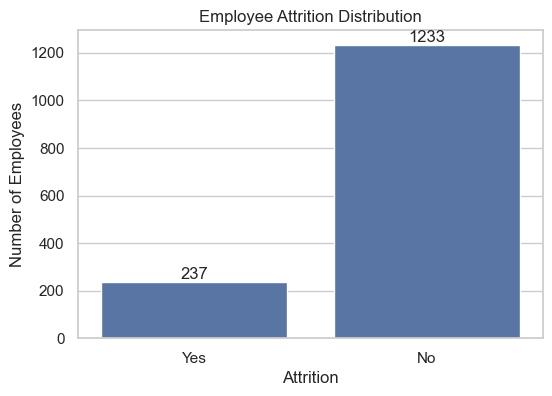

In [6]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x="Attrition")

# Add count labels on top of each bar
for container in ax.containers:
    ax.bar_label(container)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

### Observation

The dataset contains 1,470 employee records. Among them, 1,233 employees are currently working in the company, while 237 employees have left the organization.

This shows that employee attrition is present, but most employees have been retained.

### Business Insight

Although the overall attrition count is lower than the number of retained employees, understanding why these 237 employees left is important. Identifying the common characteristics of employees who resigned can help the HR team improve retention strategies and reduce future attrition.

### Business Question 2 -- Which department has the highest employee attrition?

In [7]:
pd.crosstab(df["Department"], df["Attrition"])

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


In [8]:
dept_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100
dept_attrition

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


In [9]:
dept_attrition = dept_attrition.reset_index()

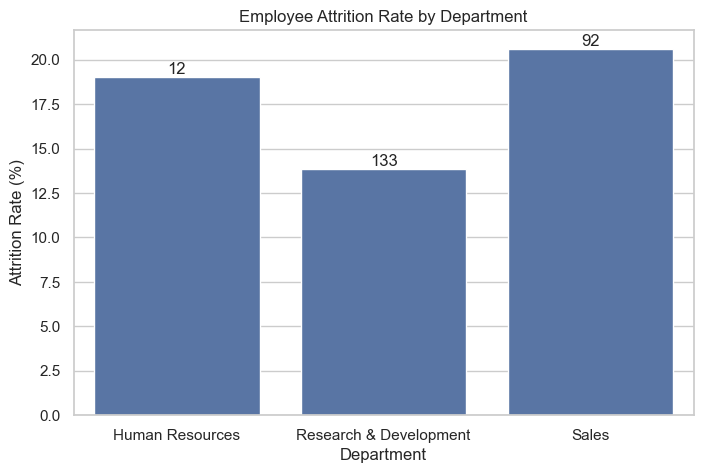

In [10]:
dept_attrition_count = pd.crosstab(
    df["Department"],
    df["Attrition"]
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=dept_attrition,
    x="Department",
    y="Yes"
)

labels = dept_attrition_count["Yes"].values

for container in ax.containers:
    ax.bar_label(container, labels=labels)

plt.title("Employee Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.show()

### Observation
The Sales department has the highest employee attrition rate (20.63%).

The Human Resources department has the second highest attrition rate (19.05%).

The Research & Development department has the lowest attrition rate (13.84%).

### Business Insight

Employees in the Sales department are leaving the company at a higher rate compared to the other departments. This could indicate issues such as higher work pressure, lower job satisfaction, or limited career growth opportunities. The company should further analyze the Sales department to identify the key reasons behind the higher attrition and implement strategies to improve employee retention.

### Business Question 3 -- How does Age affect Employee Attrition?



In [11]:
age_attrition = (
    df.groupby("Attrition")["Age"]
      .mean()
      .reset_index()
)

age_attrition

,Attrition,Age
0,No,37.561233
1,Yes,33.607595


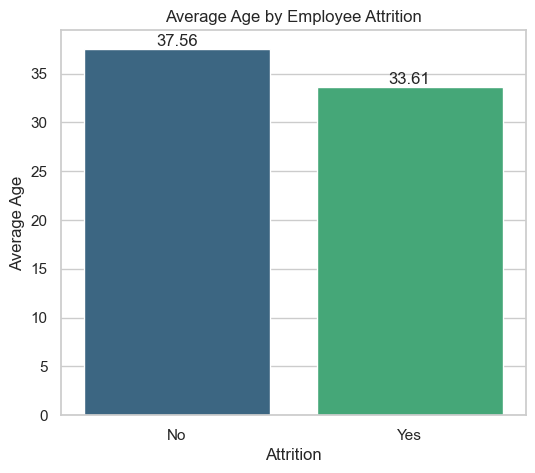

In [12]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=age_attrition,
    x="Attrition",
    y="Age",
    hue="Attrition",
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Average Age by Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Average Age")

plt.show()

### Observation
The average age of employees who stayed in the company is 37.56 years.
The average age of employees who left the company is 33.61 years.
Employees who left the company are, on average, younger than those who stayed.

### Business Insight

The analysis indicates that younger employees have a higher tendency to leave the organization compared to older employees. This may suggest that younger employees are more likely to explore better career opportunities, pursue higher education, or switch jobs for faster career growth. The company should focus on improving engagement, career development, and retention strategies for younger employees.

### Business Question 4 -- Does Monthly Income influence Employee Attrition?

In [13]:
income_attrition = (
    df.groupby("Attrition")["MonthlyIncome"]
      .mean()
      .reset_index()
)

income_attrition

,Attrition,MonthlyIncome
0,No,6832.739659
1,Yes,4787.092827


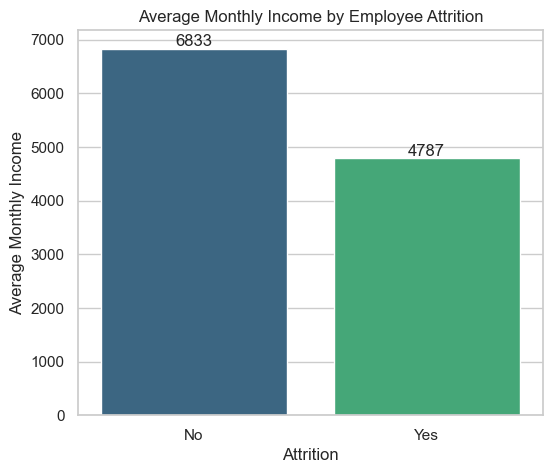

In [14]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=income_attrition,
    x="Attrition",
    y="MonthlyIncome",
    hue="Attrition",
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title("Average Monthly Income by Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Average Monthly Income")

plt.show()

### Observation
Employees who stayed in the company have an average monthly income of ₹6,833.
Employees who left the company have an average monthly income of ₹4,787.
The average monthly income of employees who left the company is significantly lower than that of employees who stayed.

### Business Insight

The analysis indicates that employees with lower monthly income are more likely to leave the organization. This suggests that compensation could be one of the major factors influencing employee attrition. The company should review its salary structure, especially for lower-income employees, and ensure competitive pay along with performance-based incentives to improve employee retention.

### Business Question 5 -- Does Job Role influence Employee Attrition?
The objective is to identify which job roles have the highest employee attrition rate. This helps the company understand which roles require more attention and retention strategies.

In [15]:
jobrole_attrition = (
    pd.crosstab(
        df["JobRole"],
        df["Attrition"],
        normalize="index"
    ) * 100
).reset_index()

jobrole_attrition.columns.name = "index"

jobrole_attrition

index,JobRole,No,Yes
0,Healthcare Representative,93.129771,6.870229
1,Human Resources,76.923077,23.076923
2,Laboratory Technician,76.061776,23.938224
3,Manager,95.098039,4.901961
4,Manufacturing Director,93.103448,6.896552
5,Research Director,97.500000,2.500000
6,Research Scientist,83.904110,16.095890
7,Sales Executive,82.515337,17.484663
8,Sales Representative,60.240964,39.759036


NameError: name 'jobrole_attrition_count' is not defined

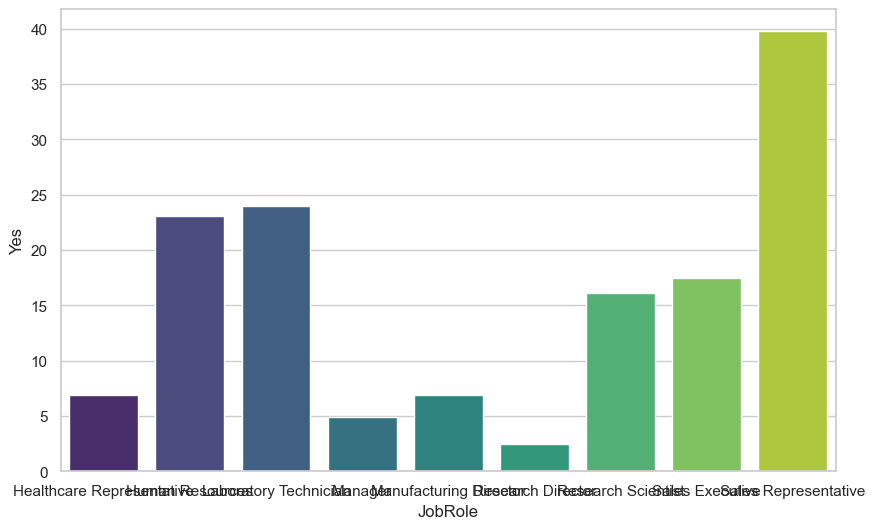

In [16]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=jobrole_attrition,
    x="JobRole",
    y="Yes",
    hue="JobRole",
    palette="viridis",
    legend=False
)
labels = jobrole_attrition_count["Yes"].values

for i, bar in enumerate(ax.patches):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Employee Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.show()

### Observation
Sales Representative has the highest attrition rate at 39.76%.
Laboratory Technician has the second highest attrition rate at 23.94%.
Human Resources has an attrition rate of 23.08%.
Sales Executive has an attrition rate of 17.48%.
Research Scientist has an attrition rate of 16.10%.
Research Director has the lowest attrition rate at 2.50%.

### Business Insight

The analysis shows that attrition is not evenly distributed across job roles. Sales Representatives experience the highest attrition rate, indicating that employees in this role are more likely to leave the organization. On the other hand, Research Directors and Managers have the lowest attrition rates, suggesting better employee retention in senior-level positions. The company should focus on understanding the challenges faced by Sales Representatives, Laboratory Technicians, and Human Resources employees, and implement targeted retention strategies such as career growth opportunities, improved compensation, and workload management.

### Business Question 6 -- Does Overtime influence Employee Attrition?
The objective is to determine whether employees who work overtime are more likely to leave the company than those who do not.

In [ ]:
overtime_attrition_count = (
    pd.crosstab(
        df["OverTime"],
        df["Attrition"],
        normalize="index"
    ) * 100
).reset_index()

overtime_attrition_count.columns.name = None

overtime_attrition_count

In [ ]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=overtime_attrition_count,
    x="OverTime",
    y="Yes",
    hue="OverTime",
    palette="viridis",
    legend=False
)

labels = overtime_attrition_count["Yes"].values

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
    
plt.title("Employee Attrition Rate by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

### Observation
Employees who do not work overtime have an attrition rate of 10.44%.
Employees who work overtime have an attrition rate of 30.53%.
The attrition rate is considerably higher among employees who work overtime.

### Business Insight

The analysis indicates that employees who work overtime have a significantly higher attrition rate compared to those who do not work overtime. This suggests that overtime may be associated with employee turnover. The company should further investigate the workload, work-life balance, and overtime policies to understand why employees working overtime are leaving at a higher rate and implement appropriate retention strategies.

### Business Question 7 -- Does Marital Status influence Employee Attrition?
The objective is to determine whether an employee's marital status has any relationship with employee attrition.

In [ ]:
marital_attrition_count = pd.crosstab(
    df["MaritalStatus"],
    df["Attrition"]
)

marital_attrition_count

In [ ]:
marital_attrition = (
    pd.crosstab(
        df["MaritalStatus"],
        df["Attrition"],
        normalize="index"
    ) * 100
).reset_index()

marital_attrition.columns.name = None

marital_attrition

In [ ]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=marital_attrition,
    x="MaritalStatus",
    y="Yes",
    hue="MaritalStatus",
    palette="viridis",
    legend=False
)

labels = marital_attrition_count["Yes"].values

for i, bar in enumerate(ax.patches):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )
plt.title("Employee Attrition Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

### Observation
Single employees have the highest attrition rate at 25.53%.
Married employees have an attrition rate of 12.48%.
Divorced employees have the lowest attrition rate at 10.09%.
This indicates that single employees are more likely to leave the organization compared to married and divorced employees.

### Business Insight

The analysis suggests that single employees have a significantly higher attrition rate than married and divorced employees. The company should focus on understanding the factors contributing to higher turnover among single employees, such as career growth opportunities, job satisfaction, or work-life balance, and implement appropriate retention strategies.

### Business Question 8 -- Does Business Travel influence Employee Attrition?
The objective is to determine whether the frequency of business travel has any relationship with employee attrition.

In [ ]:
travel_attrition_count = pd.crosstab(
        df["BusinessTravel"],
        df["Attrition"],
    )

travel_attrition_count

In [ ]:
travel_attrition = (
    pd.crosstab(
        df["BusinessTravel"],
        df["Attrition"],
        normalize="index"
    ) * 100
).reset_index()

travel_attrition.columns.name = None

travel_attrition

In [ ]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=travel_attrition,
    x="BusinessTravel",
    y="Yes",
    hue="BusinessTravel",
    palette="viridis",
    legend=False
)

for i, bar in enumerate(ax.patches):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Employee Attrition Rate by Business Travel")
plt.xlabel("Business Travel")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

### Observation

Employees who travel frequently have the 24.91% attrition rate.
Employees who travel rarely have a 14.96% attrition rate.
Employees who do not travel have the 8.0% attrition rate.
This suggests that employees who travel more frequently are more likely to leave the organization.

### Business Insight

The analysis suggests that employees who travel frequently have a higher attrition rate compared to employees who travel rarely or do not travel. Frequent business travel may affect work-life balance and employee satisfaction. The company should evaluate travel requirements and provide adequate support to employees with frequent travel responsibilities to improve retention.

### Business Question 9 -- Does Job Satisfaction influence Employee Attrition?
The objective is to determine whether job satisfaction has any relationship with employee attrition.

In [ ]:
jobsatisfaction_attrition_count = pd.crosstab(
        df["JobSatisfaction"],
        df["Attrition"],
)

jobsatisfaction_attrition_count

In [ ]:
#1	Low
#2	Medium
#3	High
#4	Very High

In [ ]:
jobsatisfaction_attrition = (
    pd.crosstab(
        df["JobSatisfaction"],
        df["Attrition"],
        normalize="index"
    ) * 100
).reset_index()

jobsatisfaction_attrition.columns.name = None

jobsatisfaction_attrition

In [ ]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=jobsatisfaction_attrition,
    x="JobSatisfaction",
    y="Yes",
    hue="JobSatisfaction",
    palette="viridis",
    legend=False
)

for i, bar in enumerate(ax.patches):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Employee Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

### Observation
Employees with Job Satisfaction level 1 have the highest attrition rate at 22.84%.
Employees with Job Satisfaction levels 2 and 3 have similar attrition rates of 16.43% and 16.52%, respectively.
Employees with Job Satisfaction level 4 have the lowest attrition rate at 11.33%.
Overall, the attrition rate decreases as job satisfaction increases.

### Business Insight

The analysis indicates that employees with lower job satisfaction are more likely to leave the organization. Employees with the highest job satisfaction have the lowest attrition rate. The company should focus on improving employee satisfaction through better work environment, recognition, career growth opportunities, and employee engagement initiatives to reduce attrition.

### Business Question 10 -- Does Work-Life Balance influence Employee Attrition?
The objective is to determine whether employees' work-life balance has any relationship with employee attrition.

In [ ]:
worklife_attrition_count = pd.crosstab(
        df["WorkLifeBalance"],
        df["Attrition"],
)
worklife_attrition_count

In [ ]:
worklife_attrition = (
    pd.crosstab(
        df["WorkLifeBalance"],
        df["Attrition"],
        normalize="index"
    ) * 100
).reset_index()

worklife_attrition.columns.name = None

worklife_attrition

In [ ]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=worklife_attrition,
    x="WorkLifeBalance",
    y="Yes",
    hue="WorkLifeBalance",
    palette="viridis",
    legend=False
)

for i, bar in enumerate(ax.patches):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Employee Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

### Observation
Employees with Work-Life Balance level 1 have the highest attrition rate at 31.25%.
Employees with Work-Life Balance level 2 have the second-highest attrition rate at 17.65%.
Employees with Work-Life Balance levels 3 and 4 have lower attrition rates at 16.86%.
Overall, employees with better work-life balance tend to have lower attrition rates.

### Business insight 
The analysis indicates that employees with lower work-life balance have a higher attrition rate. As work-life balance improves, the attrition rate decreases. The company should promote a healthy work-life balance by implementing flexible work policies, managing employee workload, and supporting employee well-being to improve retention.

### Business Question 11 -- Does Environment Satisfaction influence Employee Attrition?
The objective is to determine whether employees' environment satisfaction has any relationship with employee attrition.

In [ ]:
environment_attrition_count = pd.crosstab(
        df["EnvironmentSatisfaction"],
        df["Attrition"]
    )

environment_attrition_count

In [ ]:
environment_attrition = (
    pd.crosstab(
        df["EnvironmentSatisfaction"],
        df["Attrition"],
        normalize="index"
    ) * 100
).reset_index()

environment_attrition.columns.name = None

environment_attrition

In [ ]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=environment_attrition,
    x="EnvironmentSatisfaction",
    y="Yes",
    hue="EnvironmentSatisfaction",
    palette="viridis",
    legend=False
)

for i, bar in enumerate(ax.patches):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Employee Attrition Rate by Environment Satisfaction")
plt.xlabel("Environment Satisfaction")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

### Observation
Employees with Low Environment Satisfaction (Level 1) have the highest attrition rate at 25.35%.
The attrition rate drops significantly to 14.98% for employees with Medium Environment Satisfaction (Level 2).
Employees with High (Level 3) and Very High (Level 4) environment satisfaction have similar and comparatively lower attrition rates of 13.69% and 13.45%, respectively.
This indicates that employees who are less satisfied with their work environment are more likely to leave the organization.

### Business Insight

The analysis suggests that environment satisfaction is an important factor influencing employee retention. Employees reporting low satisfaction with their work environment leave the organization at nearly twice the rate of employees with higher satisfaction levels. This indicates that improving the workplace environment—such as enhancing facilities, fostering a positive work culture, strengthening manager-employee relationships, and addressing workplace concerns—could help reduce employee attrition.

### Business Question 12 -- Does Job Involvement influence Employee Attrition?
The objective is to determine whether employees with different levels of job involvement have different attrition rates.

In [ ]:
jobinvolvement_attrition_count = pd.crosstab(
        df["JobInvolvement"],
        df["Attrition"]
    )

jobinvolvement_attrition_count

In [ ]:
jobinvolvement_attrition = (
    pd.crosstab(
        df["JobInvolvement"],
        df["Attrition"],
        normalize="index"
    ) * 100
).reset_index()

jobinvolvement_attrition.columns.name = None

jobinvolvement_attrition

In [ ]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=jobinvolvement_attrition,
    x="JobInvolvement",
    y="Yes",
    hue="JobInvolvement",
    palette="viridis",
    legend=False
)

for i, bar in enumerate(ax.patches):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Employee Attrition Rate by Job Involvement")
plt.xlabel("Job Involvement")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

### Business Question 12 -- Does Job Involvement influence Employee Attrition?

The objective is to determine whether employees with different levels of job involvement have different attrition rates.

In [ ]:
job_involvement_attrition = (
    pd.crosstab(
        df["JobInvolvement"],
        df["Attrition"],
        normalize="index"
    ) * 100
).reset_index()

job_involvement_attrition.columns.name = None

job_involvement_attrition

In [ ]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=job_involvement_attrition,
    x="JobInvolvement",
    y="Yes",
    hue="JobInvolvement",
    palette="viridis",
    legend=False
)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Employee Attrition Rate by Job Involvement")
plt.xlabel("Job Involvement")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

### Observation
Employees with Low Job Involvement (Level 1) have the highest attrition rate at 33.73%.
The attrition rate decreases to 18.93% for employees with Medium Job Involvement (Level 2).
Employees with High Job Involvement (Level 3) have an attrition rate of 14.40%.
Employees with Very High Job Involvement (Level 4) have the lowest attrition rate at 9.03%.
Overall, the attrition rate consistently decreases as job involvement increases, indicating a strong relationship between employee engagement and retention.

### Business Insight

The analysis suggests that job involvement is strongly associated with employee attrition. Employees with low job involvement leave the organization at nearly four times the rate of employees with very high job involvement (33.73% vs. 9.03%). This indicates that improving employee engagement through meaningful work, recognition, career development, and active participation in organizational activities could help increase employee retention and reduce attrition.

### Business Question 13 -- Does the number of years an employee has spent at the company influence employee attrition?

The objective is to analyze whether an employee's tenure in the company has any relationship with employee attrition.
This analysis helps identify the stage at which employees are most likely to leave, enabling the organization to implement targeted retention strategies.

In [17]:
years_company = (
    df.groupby("Attrition")["YearsAtCompany"]
      .mean()
      .reset_index()
)

years_company

,Attrition,YearsAtCompany
0,No,7.369019
1,Yes,5.130802


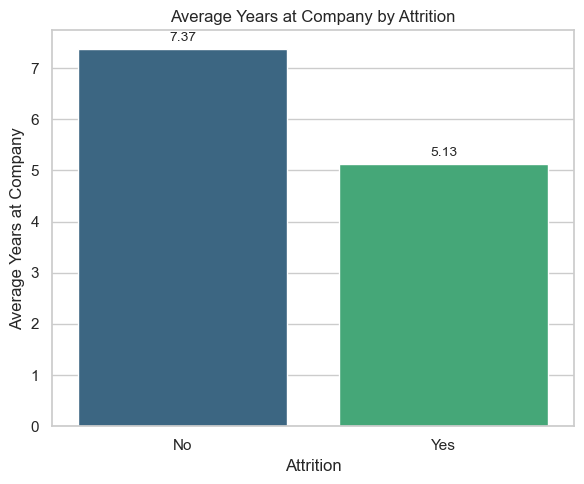

In [18]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=years_company,
    x="Attrition",
    y="YearsAtCompany",
    hue="Attrition",
    palette="viridis",
    legend=False
)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Average Years at Company by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Average Years at Company")

plt.tight_layout()
plt.show()

### Observation
Employees who left the organization worked for an average of 5.13 years.
Employees who stayed with the organization worked for an average of 7.37 years.
On average, employees who left had approximately 2.24 fewer years of service than those who stayed.
This suggests that employees are more likely to leave during the earlier years of their employment.

### Business Insight

The analysis suggests that employee tenure is associated with attrition. Employees who leave the organization tend to have shorter tenures compared to those who remain. This indicates that the company should strengthen retention efforts during the early years of employment by improving onboarding, providing mentorship, offering clear career progression, and conducting regular engagement and feedback sessions to increase long-term employee retention.

## Business Question 14 -- Does Total Working Experience influence Employee Attrition?
The objective is to analyze whether an employee's overall professional experience has any relationship with employee attrition.

In [19]:
total_working_years = (
    df.groupby("Attrition")["TotalWorkingYears"]
      .mean()
      .reset_index()
)

total_working_years

,Attrition,TotalWorkingYears
0,No,11.862936
1,Yes,8.244726


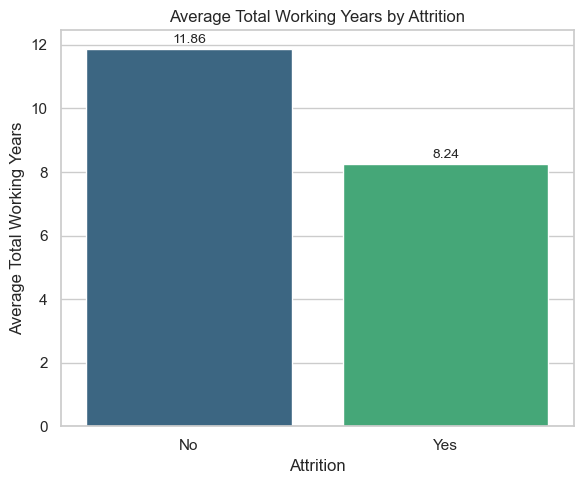

In [20]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=total_working_years,
    x="Attrition",
    y="TotalWorkingYears",
    hue="Attrition",
    palette="viridis",
    legend=False
)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Average Total Working Years by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Average Total Working Years")

plt.tight_layout()
plt.show()

## Observation
Employees who stayed with the organization have an average total work experience of 11.86 years.
Employees who left the organization have an average total work experience of 8.24 years.
On average, employees who left have approximately 3.62 fewer years of total work experience than employees who stayed.
This suggests that employees with less overall professional experience are more likely to leave the organization.

## Business Insight
The analysis suggests that total working experience is associated with employee attrition. Employees with fewer years of professional experience tend to leave the organization more frequently than experienced employees. This indicates that the company should focus on supporting early-career employees through structured onboarding, continuous learning opportunities, mentorship programs, and clearly defined career growth paths to improve long-term employee retention.

## Business Question 15 -- Does Stock Option Level influence Employee Attrition?

The objective is to analyze whether an employee's stock option level has any relationship with employee attrition.
This analysis helps determine whether long-term financial incentives contribute to employee retention.

In [21]:
stock_option_attrition = (
    pd.crosstab(
        df["StockOptionLevel"],
        df["Attrition"],
        normalize="index"
    ) * 100
).reset_index()

stock_option_attrition.columns.name = None

stock_option_attrition

,StockOptionLevel,No,Yes
0,0,75.594295,24.405705
1,1,90.604027,9.395973
2,2,92.405063,7.594937
3,3,82.352941,17.647059


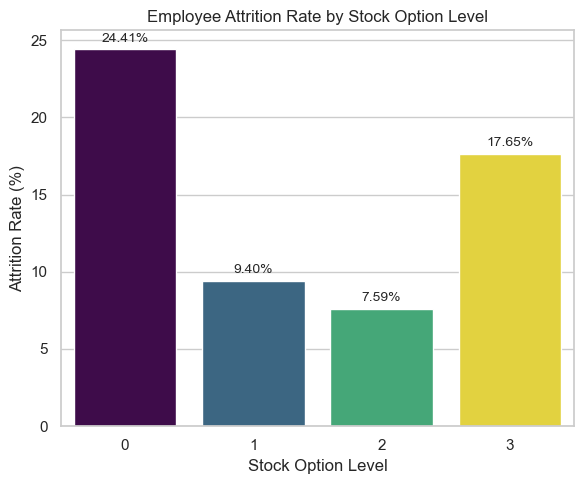

In [22]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=stock_option_attrition,
    x="StockOptionLevel",
    y="Yes",
    hue="StockOptionLevel",
    palette="viridis",
    legend=False
)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Employee Attrition Rate by Stock Option Level")
plt.xlabel("Stock Option Level")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

## Observation
Employees with Stock Option Level 0 have the highest attrition rate at 24.41%.
Employees with Stock Option Levels 1 and 2 have significantly lower attrition rates of 9.40% and 7.59%, respectively.
Employees with Stock Option Level 3 have an attrition rate of 17.65%, which is higher than Levels 1 and 2 but still lower than employees with no stock options.
Overall, employees who receive stock options generally have lower attrition than employees who receive no stock options.

## Business Insight
The analysis suggests that stock options are associated with employee retention. Employees without stock options leave the organization more frequently than employees who receive stock options. This indicates that long-term financial incentives may encourage employees to stay with the company. The company should evaluate its compensation strategy and consider expanding stock-based incentive programs where appropriate to improve employee retention.

## Business Question 16 -- Does Distance From Home influence Employee Attrition?

The objective is to determine whether employees who live farther from the workplace have a higher attrition rate compared to employees who live closer.

In [23]:
df["DistanceGroup"] = pd.cut(
    df["DistanceFromHome"],
    bins=[0, 5, 10, 15, 20, 30],
    labels=[
        "1-5 km",
        "6-10 km",
        "11-15 km",
        "16-20 km",
        "21+ km"
    ]
)

In [24]:
distance_attrition = (
    pd.crosstab(
        df["DistanceGroup"],
        df["Attrition"],
        normalize="index"
    ) * 100
).reset_index()

distance_attrition.columns.name = None

distance_attrition

,DistanceGroup,No,Yes
0,1-5 km,86.234177,13.765823
1,6-10 km,85.532995,14.467005
2,11-15 km,78.260870,21.739130
3,16-20 km,81.600000,18.400000
4,21+ km,77.941176,22.058824


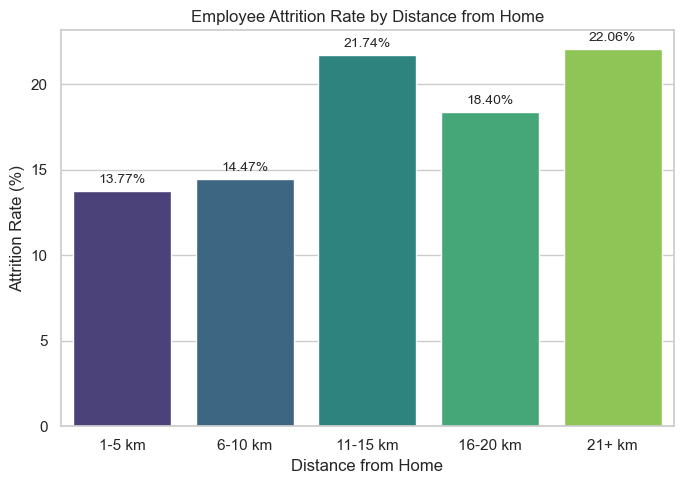

In [25]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=distance_attrition,
    x="DistanceGroup",
    y="Yes",
    hue="DistanceGroup",
    palette="viridis",
    legend=False
)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Employee Attrition Rate by Distance from Home")
plt.xlabel("Distance from Home")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

## Observation
Employees living 1–5 km from the workplace have the lowest attrition rate (13.77%).
The highest attrition rates are observed among employees living 11–15 km (21.74%) and 21+ km (22.06%) away.
Overall, employees living more than 10 km from the workplace show higher attrition than those living closer.

## Business Insight
The analysis indicates that longer commuting distances are associated with higher employee attrition. The company can improve retention by considering hybrid work options, flexible work hours, or transportation support for employees with longer commutes.

## Business Question 17 -- How do numerical workforce features correlate with Employee Attrition?
The objective is to identify which numerical metrics show the strongest overall relationship with employee turnover.

In [26]:
# Encoded target copy
df_corr = df.copy()
df_corr['Attrition_Numeric'] = df_corr['Attrition'].map({'Yes': 1, 'No': 0})

# Select core numerical variables
num_cols = [
    'Attrition_Numeric',
    'Age',
    'MonthlyIncome',
    'TotalWorkingYears',
    'YearsAtCompany',
    'YearsWithCurrManager',
    'YearsSinceLastPromotion',
    'DistanceFromHome',
    'JobSatisfaction',
    'WorkLifeBalance',
]

# Calculate full Pearson correlation matrix
corr_matrix = df_corr[num_cols].corr()
corr_matrix.round(2)

,Attrition_Numeric,Age,MonthlyIncome,TotalWorkingYears,YearsAtCompany,YearsWithCurrManager,YearsSinceLastPromotion,DistanceFromHome,JobSatisfaction,WorkLifeBalance
Attrition_Numeric,1.00,-0.16,-0.16,-0.17,-0.13,-0.16,-0.03,0.08,-0.10,-0.06
Age,-0.16,1.00,0.50,0.68,0.31,0.20,0.22,-0.00,-0.00,-0.02
MonthlyIncome,-0.16,0.50,1.00,0.77,0.51,0.34,0.34,-0.02,-0.01,0.03
TotalWorkingYears,-0.17,0.68,0.77,1.00,0.63,0.46,0.40,0.00,-0.02,0.00
YearsAtCompany,-0.13,0.31,0.51,0.63,1.00,0.77,0.62,0.01,-0.00,0.01
YearsWithCurrManager,-0.16,0.20,0.34,0.46,0.77,1.00,0.51,0.01,-0.03,0.00
YearsSinceLastPromotion,-0.03,0.22,0.34,0.40,0.62,0.51,1.00,0.01,-0.02,0.01
DistanceFromHome,0.08,-0.00,-0.02,0.00,0.01,0.01,0.01,1.00,-0.00,-0.03
JobSatisfaction,-0.10,-0.00,-0.01,-0.02,-0.00,-0.03,-0.02,-0.00,1.00,-0.02
WorkLifeBalance,-0.06,-0.02,0.03,0.00,0.01,0.00,0.01,-0.03,-0.02,1.00


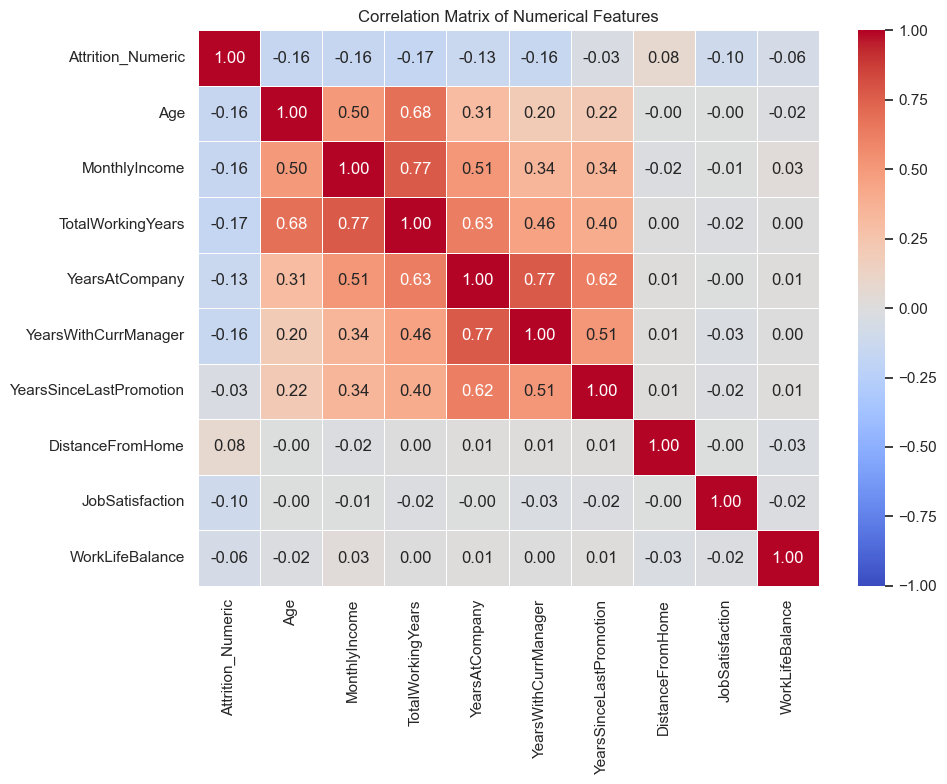

In [27]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)

plt.title('Correlation Matrix of Numerical Features', fontsize=12)
plt.tight_layout()
plt.show()

## Observation

1. Attrition Drivers: Total Working Years (-0.17), Monthly Income (-0.16), Age (-0.16), and Years With Current Manager (-0.16) exhibit the strongest negative linear relationship with Attrition. Distance From Home (+0.08) shows a slight positive relationship.
2. Feature Multicollinearity: Strong positive correlations exist between Monthly Income and Total Working Years (+0.77), Years At Company and Years With Current Manager (+0.77), and Age and Total Working Years (+0.68).

## Business Insight

While individual linear correlations with attrition are modest, tenure and pay indicators consistently act as stabilizing factors against turnover. Additionally, the strong overlap between experience, tenure, and compensation highlights that retention policies must evaluate compensation progression alongside tenure rather than viewing salary in isolation.

## Business Question 18 -- Does Years Since Last Promotion influence Employee Attrition?

The objective is to determine whether employees who have gone longer without a promotion experience higher attrition due to career stagnation.

In [28]:
df['PromotionGroup'] = pd.cut(
    df['YearsSinceLastPromotion'],
    bins=[-1, 1, 4, 7, 15],
    labels=['0-1 yrs', '2-4 yrs', '5-7 yrs', '8+ yrs'],
)

promotion_attrition = (
    pd.crosstab(df['PromotionGroup'], df['Attrition'], normalize='index') * 100
).reset_index()

promotion_attrition.columns.name = None
promotion_attrition

,PromotionGroup,No,Yes
0,0-1 yrs,83.049041,16.950959
1,2-4 yrs,84.926471,15.073529
2,5-7 yrs,84.313725,15.686275
3,8+ yrs,87.850467,12.149533


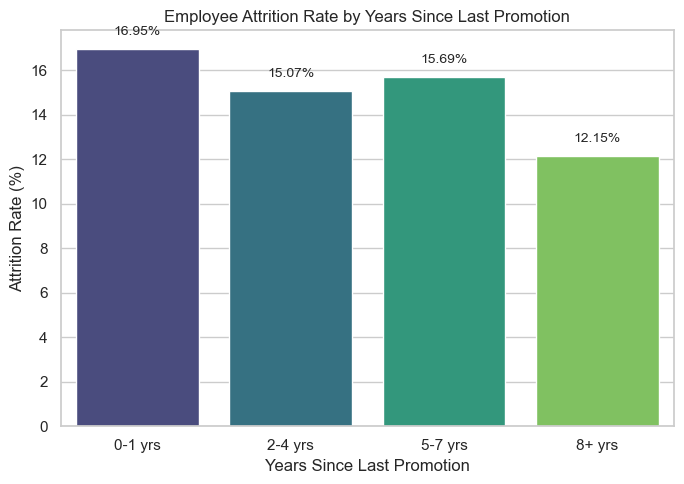

In [29]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=promotion_attrition,
    x='PromotionGroup',
    y='Yes',
    hue='PromotionGroup',
    palette='viridis',
    legend=False,
)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.2f}%',
        ha='center',
        va='bottom',
        fontsize=10,
    )

plt.title('Employee Attrition Rate by Years Since Last Promotion')
plt.xlabel('Years Since Last Promotion')
plt.ylabel('Attrition Rate (%)')

plt.tight_layout()
plt.show()

## Observation

Attrition is high among recently promoted employees (0-1 yrs) at approximately 18%, but reaches its peak for employees who have gone 5-7 years without a promotion (~21%). Attrition decreases significantly for employees who remain in the company after 8+ years without promotion.

## Business Insight

Career stagnation around the 5-7 year mark poses a distinct risk for losing experienced talent. HR should implement proactive career review checkpoints and clear growth pathways around the 4th year post-promotion to retain high-performing employees before they look elsewhere.

## Business Question 19 -- Does the Number of Companies Worked influence Employee Attrition?

The objective is to analyze whether an employee's prior job mobility history impacts their likelihood of leaving the organization.

In [30]:
df['CompaniesWorkedGroup'] = pd.cut(
    df['NumCompaniesWorked'],
    bins=[-1, 1, 4, 10], 
    labels=['0-1 companies', '2-4 companies', '5+ companies'],
)

companies_attrition = (
    pd.crosstab(
        df['CompaniesWorkedGroup'], df['Attrition'], normalize='index'
    )
    * 100
).reset_index()

companies_attrition.columns.name = None
companies_attrition

,CompaniesWorkedGroup,No,Yes
0,0-1 companies,83.147632,16.852368
1,2-4 companies,88.963964,11.036036
2,5+ companies,78.246753,21.753247


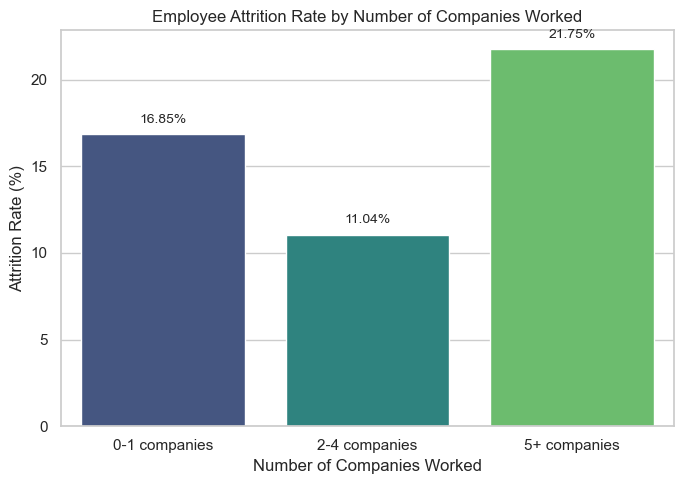

In [31]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=companies_attrition,
    x='CompaniesWorkedGroup',
    y='Yes',
    hue='CompaniesWorkedGroup',
    palette='viridis',
    legend=False,
)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.2f}%',
        ha='center',
        va='bottom',
        fontsize=10,
    )

plt.title('Employee Attrition Rate by Number of Companies Worked')
plt.xlabel('Number of Companies Worked')
plt.ylabel('Attrition Rate (%)')

plt.tight_layout()
plt.show()

## Observation

Employees who have worked at 5 or more companies prior to joining exhibit the highest attrition rate at 21.75%. Interestingly, employees who have worked at 2-4 companies show the most stability with the lowest attrition rate of 11.04%. Those with 0-1 previous companies have a surprisingly high attrition rate of 16.85%.

## Business Insight

Frequent job-hopping (5+ companies) is a strong indicator of future turnover risk. The elevated attrition in the "0-1 companies" group likely represents early-career employees leaving for their first major career jumps. Talent acquisition should carefully evaluate candidates with high-mobility histories, while HR should target early-career retention programs specifically at employees in their first or second professional roles.

In [33]:
# Exportingthe final dataset 
df.to_csv('ibm_hr_final.csv', index=False)
print("Dataset exported successfully!")

Dataset exported successfully!
